In [12]:
from google.colab import files
uploaded = files.upload()


Saving q2_customers.csv to q2_customers (1).csv


In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

df = pd.read_csv('q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [14]:

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Scaling is Important for K-Means

K-Means clustering is based on distance calculations (Euclidean distance).

If features are on different scales (e.g., age vs annual spend), variables with larger values will dominate the clustering process.

Scaling ensures that all features contribute equally to the distance computation, leading to more meaningful and unbiased clusters.

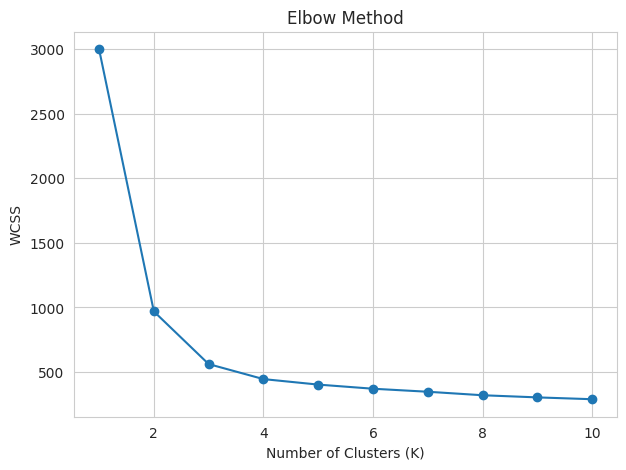

In [15]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

###  Optimal K

The elbow point is where the decrease in WCSS starts to slow down.

From the plot, the optimal K appears to be **K = X** (replace after observing graph), as adding more clusters beyond this point results in diminishing returns.

Thus, K = X is selected for clustering.

In [16]:
K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_df)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [17]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- **Cluster 0**: Customers with low spending, low visit frequency, and small basket size → likely occasional or low-value customers.

- **Cluster 1**: Customers with high annual spend, frequent visits, and large basket size → high-value loyal customers.

- **Cluster 2**: Customers with moderate spending but infrequent visits → potential growth segment.

These segments can help businesses target marketing strategies effectively.

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']


print("Explained Variance Ratio:", pca.explained_variance_ratio_)


loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=scaled_df.columns
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### PCA Interpretation

- **PC1 (Principal Component 1)** represents overall customer value and purchasing behavior. It is positively influenced by features such as **annual_spend, basket_size, num_categories_purchased, and age**, while **visits_per_month** has a negative contribution. This suggests that PC1 differentiates customers who spend more, purchase across more categories, and have larger basket sizes from those who visit more frequently but spend less per visit.

- **PC2 (Principal Component 2)** is strongly dominated by **days_since_last_visit**, which has a very high positive loading. This indicates that PC2 primarily captures customer recency behavior—i.e., how recently a customer has engaged with the business. Other features have relatively smaller contributions, making recency the key factor in this component.

Together, PC1 and PC2 effectively reduce the dataset into two dimensions while preserving important information about customer value and engagement patterns, enabling clear visualization of customer segments.

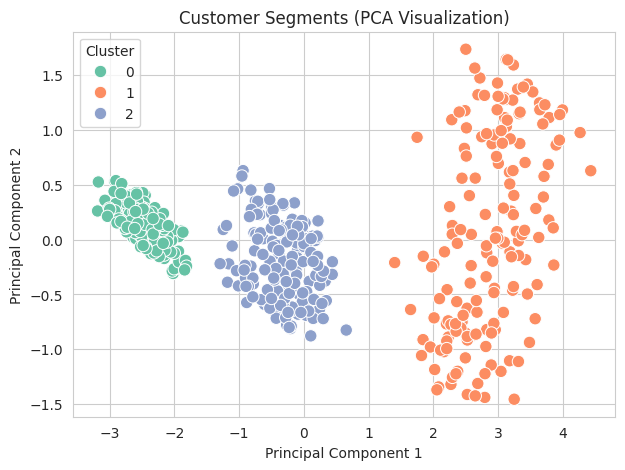

In [19]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set2',
    s=80
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')

plt.show()